In [1]:
import json
import sqlite3
from pathlib import Path

import pandas as pd


ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATABASE = ROOT / "data" / "clinica.db"
RATES_PATH = ROOT / "data" / "tarifas_especialidad.csv"
CATALOG_PATH = ROOT / "data" / "catalogo_clinicas.json"
PROFILE_PATH = ROOT / "data" / "data_profile.json"

with sqlite3.connect(DATABASE) as connection:
    patients = pd.read_sql_query("SELECT * FROM patients", connection)
    appointments = pd.read_sql_query("SELECT * FROM appointments", connection)

rates = pd.read_csv(RATES_PATH)

with CATALOG_PATH.open(encoding="utf-8") as file:
    catalog = json.load(file)

clinics = pd.DataFrame(catalog["clinicas"])

specialty_aliases = pd.DataFrame([
    {"specialty": specialty, "aliases": aliases}
    for specialty, aliases in catalog["especialidad_aliases"].items()
])

print("Fuentes cargadas correctamente")

Fuentes cargadas correctamente


In [3]:
summary = pd.DataFrame({
    "fuente": [
        "clinica.db - patients",
        "clinica.db - appointments",
        "tarifas_especialidad.csv",
        "catalogo_clinicas.json - clinicas",
        "catalogo_clinicas.json - especialidades",
    ],
    "filas": [
        patients.shape[0],
        appointments.shape[0],
        rates.shape[0],
        clinics.shape[0],
        specialty_aliases.shape[0],
    ],
    "columnas": [
        patients.shape[1],
        appointments.shape[1],
        rates.shape[1],
        clinics.shape[1],
        specialty_aliases.shape[1],
    ],
})

display(summary)

print("patient_id únicos en patients:", patients["patient_id"].nunique())
print("patient_id únicos en appointments:", appointments["patient_id"].nunique())

,fuente,filas,columnas
0,clinica.db - patients,8000,6
1,clinica.db - appointments,61200,10
2,tarifas_especialidad.csv,40,5
3,catalogo_clinicas.json - clinicas,5,5
4,catalogo_clinicas.json - especialidades,8,2


patient_id únicos en patients: 8000
patient_id únicos en appointments: 8314


### Interpretación

La tabla `patients` tiene 8000 pacientes. La tabla `appointments` tiene 61200 filas porque se generaron 60000 citas y D4 agregó 1200 duplicados. En las citas aparecen 8314 porque algunos no pertenecen a pacientes reales debido al defecto D1.

In [4]:
def nulls(df, source):  # Calcula los nulos de cada columna
    result = pd.DataFrame({
        "fuente": source,
        "columna": df.columns,
        "nulos": df.isna().sum().values,
        "porcentaje": (df.isna().mean().values * 100).round(2),
    })

    return result


null_report = pd.concat([
    nulls(patients, "patients"),
    nulls(appointments, "appointments"),
    nulls(rates, "tarifas_especialidad.csv"),
    nulls(clinics, "catalogo - clinicas"),
    nulls(specialty_aliases, "catalogo - especialidades"),
], ignore_index=True)

display(null_report)

,fuente,columna,nulos,porcentaje
0,patients,patient_id,0,0.00
1,patients,birth_date,0,0.00
2,patients,sex,0,0.00
3,patients,city,0,0.00
4,patients,insurance,0,0.00
5,patients,registered_at,0,0.00
6,appointments,appointment_id,0,0.00
7,appointments,patient_id,0,0.00
8,appointments,clinic_code,0,0.00
9,appointments,specialty,900,1.47


### Interpretación

Los nulos aparecen únicamente en `appointments`. La columna `specialty` tiene 900 nulos y `amount_charged` tiene 900 nulos. En conjunto son las 1,800 filas modificadas por D3. El porcentaje individual es aproximadamente 1.47% porque cada mitad se calcula sobre las 61,200 filas finales.

In [5]:
valid_specialties = set(catalog["especialidad_aliases"].keys())
valid_clinics = {clinic["clinic_code"] for clinic in catalog["clinicas"]}

bad_specialty = appointments["specialty"].notna() & ~appointments["specialty"].isin(valid_specialties)
bad_clinic = appointments["clinic_code"].notna() & ~appointments["clinic_code"].isin(valid_clinics)

specialty_values = appointments["specialty"].value_counts(dropna=False).rename_axis("specialty").reset_index(name="filas")
clinic_values = appointments["clinic_code"].value_counts(dropna=False).rename_axis("clinic_code").reset_index(name="filas")

display(specialty_values)
display(clinic_values)

print("Especialidades con nomenclatura incorrecta:", bad_specialty.sum())
print("Clínicas con nomenclatura incorrecta:", bad_clinic.sum())

,specialty,filas
0,Dermatología,7224
1,Ginecología,7220
2,Odontología,7217
3,Traumatología,7182
4,Oftalmología,7165
5,Cardiología,7138
6,Medicina General,7089
7,Pediatría,7065
8,NaN,900
9,GINE,214


,clinic_code,filas
0,CL01,17924
1,CL02,15172
2,CL03,11975
3,CL04,8846
4,CL05,6083
5,'CL01',346
6,'CL02',305
7,'CL03',250
8,'CL04',180
9,'CL05',119


Especialidades con nomenclatura incorrecta: 3000
Clínicas con nomenclatura incorrecta: 1200


### Interpretación

Se encontraron 3000 citas con alias de especialidades correspondientes a D5. También se encontraron 1200 códigos de clínica con comillas y espacios correspondientes a D6. Estas diferencias deben normalizarse antes de realizar la integración con las tarifas.

In [6]:
exact_duplicate_rows = appointments.duplicated(keep="first")
duplicate_id_rows = appointments.duplicated(subset=["appointment_id"], keep="first")
almost_duplicate_rows = duplicate_id_rows & ~exact_duplicate_rows

print("Duplicados exactos:", exact_duplicate_rows.sum())
print("Casi duplicados:", almost_duplicate_rows.sum())
print("Total por appointment_id repetido:", duplicate_id_rows.sum())

duplicate_ids = appointments.loc[
    appointments.duplicated(subset=["appointment_id"], keep=False),
    "appointment_id",
].head(5)

duplicate_examples = appointments[
    appointments["appointment_id"].isin(duplicate_ids)
].sort_values("appointment_id")

display(duplicate_examples)

Duplicados exactos: 600
Casi duplicados: 600
Total por appointment_id repetido: 1200


,appointment_id,patient_id,clinic_code,specialty,scheduled_at,duration_min,status,amount_charged,payment_method,created_at
18,A0000019,P004777,CL05,Medicina General,2024-10-31 11:30:00,20,completada,2051.39,tarjeta,2024-10-24 11:30:00
60931,A0000019,P004777,CL05,Medicina General,2024-10-31 11:30:00,20,completada,2052.39,tarjeta,2024-10-24 11:30:00
22,A0000023,P005362,CL02,Ginecología,2024-03-09 13:00:00,15,completada,1103.39,tarjeta,2024-03-04 13:00:00
61107,A0000023,P005362,CL02,Ginecología,2024-03-09 13:00:00,15,completada,1104.39,tarjeta,2024-03-04 13:00:00
49,A0000050,P006105,CL03,Ginecología,2024-04-11 15:30:00,15,completada,2152.53,tarjeta,2024-03-23 15:30:00
60463,A0000050,P006105,CL03,Ginecología,2024-04-11 15:30:00,15,completada,2152.53,tarjeta,2024-03-23 15:30:00
116,A0000117,P004058,CL01,Cardiología,2025-09-30 12:30:00,30,completada,846.57,tarjeta,2025-08-18 12:30:00
60259,A0000117,P004058,CL01,Cardiología,2025-09-30 12:30:00,30,completada,846.57,tarjeta,2025-08-18 12:30:00
165,A0000166,P007277,CL02,Cardiología,2024-12-11 11:00:00,20,completada,1411.76,tarjeta,2024-11-13 11:00:00
60850,A0000166,P007277,CL02,Cardiología,2024-12-11 11:00:00,20,completada,1412.76,tarjeta,2024-11-13 11:00:00


### Interpretación

Se encontraron 600 duplicados exactos, donde todos los valores de la fila se repiten, y 600 casi duplicados, donde se repite `appointment_id` pero cambia `amount_charged`. En total, D4 agregó 1,200 filas repetidas. Deben eliminarse para evitar contar dos veces una misma cita.

In [7]:
physical_data = appointments.merge(
    patients[["patient_id", "registered_at"]],
    on="patient_id",
    how="left",
    validate="many_to_one",
)

scheduled_dates = pd.to_datetime(physical_data["scheduled_at"], format="mixed", errors="coerce", utc=True)
registered_dates = pd.to_datetime(physical_data["registered_at"], errors="coerce", utc=True)

zero_duration_with_charge = physical_data["duration_min"].eq(0) & physical_data["amount_charged"].gt(0)
before_registration = scheduled_dates < registered_dates
physical_impossible = zero_duration_with_charge | before_registration

print("Duración cero con cobro:", zero_duration_with_charge.sum())
print("Citas anteriores al registro:", before_registration.sum())
print("Total de reglas físicas imposibles:", physical_impossible.sum())

display(physical_data.loc[
    physical_impossible,
    ["appointment_id", "patient_id", "scheduled_at", "registered_at", "duration_min", "amount_charged"],
].head(10))

Duración cero con cobro: 150
Citas anteriores al registro: 150
Total de reglas físicas imposibles: 300


,appointment_id,patient_id,scheduled_at,registered_at,duration_min,amount_charged
154,A0000155,P005075,2022-05-01 00:00:00,2022-05-08,30,2084.87
240,A0000241,P001440,2025-09-01 11:30:00,2023-10-18,0,1580.09
514,A0000515,P003407,2024-01-04 12:45:00,2022-07-18,0,681.40
561,A0000562,P005397,2025-02-19 11:45:00,2022-11-18,0,526.41
637,A0000638,P000795,2024-09-19 10:15:00,2023-03-23,0,1547.04
726,A0000727,P003260,2024-05-03 14:30:00,2022-03-16,0,713.50
1357,A0001358,P003223,2025-10-24 11:15:00,2023-05-14,0,1.00
1486,A0001487,P003556,2023-06-16 00:00:00,2023-07-05,20,1801.68
2145,A0002146,P006775,2023-01-24 00:00:00,2023-03-03,45,1966.13
2251,A0002252,P000825,2023-05-07 00:00:00,2023-05-28,15,0.00


### Interpretación

Se encontraron 150 citas con duración de cero minutos y un cobro positivo. También se encontraron 150 citas programadas antes del registro del paciente. En total, D7 produjo 300 combinaciones físicamente imposibles. Estas filas deben rechazarse porque no existe información suficiente para corregirlas de manera confiable.

,grupo,porcentaje_citas
0,Top 30% de pacientes,73.7
1,Resto de pacientes,26.3


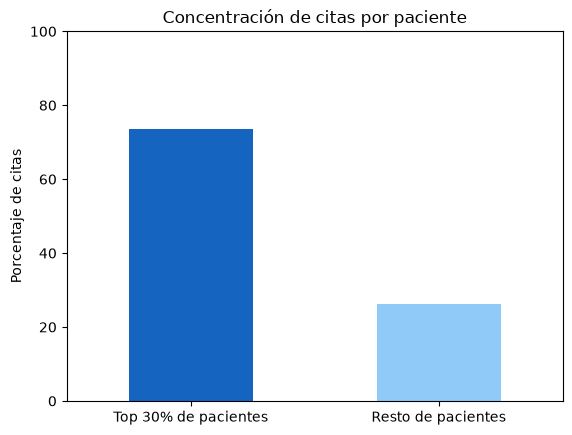

Pacientes en el top 30%: 2400
Porcentaje de citas concentradas: 73.70%


In [11]:
import matplotlib.pyplot as plt

real_appointments = appointments[
    appointments["patient_id"].isin(patients["patient_id"])
]

patient_counts = real_appointments["patient_id"].value_counts()
patient_counts = patient_counts.reindex(patients["patient_id"], fill_value=0).sort_values(ascending=False)

top_n = int(len(patients) * 0.30)
top_appointments = patient_counts.head(top_n).sum()
top_percent = top_appointments / patient_counts.sum() * 100

distribution = pd.Series({
    "Top 30% de pacientes": top_percent,
    "Resto de pacientes": 100 - top_percent,
})

display(pd.DataFrame({
    "grupo": distribution.index,
    "porcentaje_citas": distribution.values.round(2),
}))

distribution.plot(kind="bar", color=["#1565C0", "#90CAF9"])
plt.ylabel("Porcentaje de citas")
plt.title("Concentración de citas por paciente")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

print("Pacientes en el top 30%:", top_n)
print("Porcentaje de citas concentradas:", f"{top_percent:.2f}%")

### Interpretación

Los 2400 pacientes con más citas concentran aproximadamente el 73.70% de las citas válidas. Esto demuestra que las citas no están distribuidas uniformemente. En la Fase 5 puede producir data skew porque algunos grupos concentran mucho más trabajo que otros.

In [13]:
d1_detected = ~appointments["patient_id"].isin(patients["patient_id"])
d2_detected = appointments["amount_charged"].lt(0) | appointments["amount_charged"].eq(999999)
d3_detected = appointments["specialty"].isna() | appointments["amount_charged"].isna()
d5_detected = appointments["specialty"].notna() & ~appointments["specialty"].isin(valid_specialties)

standard_date = appointments["scheduled_at"].astype(str).str.match(
    r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$",
    na=False,
)

d6_detected = bad_clinic | ~standard_date

detected = {
    "D1": int(d1_detected.sum()),
    "D2": int(d2_detected.sum()),
    "D3": int(d3_detected.sum()),
    "D4": int(duplicate_id_rows.sum()),
    "D5": int(d5_detected.sum()),
    "D6": int(d6_detected.sum()),
    "D7": int(physical_impossible.sum()),
}

with PROFILE_PATH.open(encoding="utf-8") as file:
    profile = json.load(file)

comparison = pd.DataFrame({
    "defecto": list(detected.keys()),
    "detectado": list(detected.values()),
    "inyectado": [profile["defect_counts"][d] for d in detected],
})

comparison["diferencia"] = comparison["detectado"] - comparison["inyectado"]

display(comparison)

,defecto,detectado,inyectado,diferencia
0,D1,1200,1200,0
1,D2,600,600,0
2,D3,1800,1800,0
3,D4,1200,1200,0
4,D5,3000,3000,0
5,D6,2400,2400,0
6,D7,300,300,0
